# Stress Test Log Analysis
## Oil Cool Compute - CPU Temperature Analysis

Analysis of stress test runs from 2026-09-01 (latest) and 2026-08-27 (baseline), examining CPU core temperatures during thermal stress cycling and comparing thermal performance between the two runs.

## Methodology

This stress test monitors CPU core temperatures at 10-minute intervals over an extended duration. Temperature data is sampled from four CPU cores and the package sensor using the `coretemp` kernel module, capturing thermal behavior under varying computational loads. The analysis tracks temperature trends, identifies heating/cooling cycles, measures core-to-core variance, and evaluates thermal margin to ensure system stability within safe operating limits (critical threshold: 99°C).

## Setup and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

In [ ]:
# Load the CSV files (latest run is primary; earlier run is the baseline for comparison)
csv_path_new = r'c:\Users\DBA\Desktop\Engineering_Copilot_Memory\Projects\Oil_Cool_Compute\Stress_Test\stress_test_log_20260901_073639.csv'
csv_path_old = r'c:\Users\DBA\Desktop\Engineering_Copilot_Memory\Projects\Oil_Cool_Compute\Stress_Test\stress_test_log_20260827_055039.csv'

df = pd.read_csv(csv_path_new)
df_old = pd.read_csv(csv_path_old)

# Convert timestamps to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])
df_old['timestamp'] = pd.to_datetime(df_old['timestamp'])

print(f"Latest run (2026-09-01) shape: {df.shape}")
print(f"Baseline run (2026-08-27) shape: {df_old.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nFirst few rows of latest run:")
df.head()

Data shape: (144, 22)

Column names:
['timestamp', 'coretemp-isa-0000:Package id 0:temp1_input', 'coretemp-isa-0000:Package id 0:temp1_max', 'coretemp-isa-0000:Package id 0:temp1_crit', 'coretemp-isa-0000:Package id 0:temp1_crit_alarm', 'coretemp-isa-0000:Core 0:temp2_input', 'coretemp-isa-0000:Core 0:temp2_max', 'coretemp-isa-0000:Core 0:temp2_crit', 'coretemp-isa-0000:Core 0:temp2_crit_alarm', 'coretemp-isa-0000:Core 1:temp3_input', 'coretemp-isa-0000:Core 1:temp3_max', 'coretemp-isa-0000:Core 1:temp3_crit', 'coretemp-isa-0000:Core 1:temp3_crit_alarm', 'coretemp-isa-0000:Core 2:temp4_input', 'coretemp-isa-0000:Core 2:temp4_max', 'coretemp-isa-0000:Core 2:temp4_crit', 'coretemp-isa-0000:Core 2:temp4_crit_alarm', 'coretemp-isa-0000:Core 3:temp5_input', 'coretemp-isa-0000:Core 3:temp5_max', 'coretemp-isa-0000:Core 3:temp5_crit', 'coretemp-isa-0000:Core 3:temp5_crit_alarm', 'turbostat:5.002994 sec']

First few rows:


,timestamp,coretemp-isa-0000:Package id 0:temp1_input,coretemp-isa-0000:Package id 0:temp1_max,coretemp-isa-0000:Package id 0:temp1_crit,coretemp-isa-0000:Package id 0:temp1_crit_alarm,coretemp-isa-0000:Core 0:temp2_input,coretemp-isa-0000:Core 0:temp2_max,coretemp-isa-0000:Core 0:temp2_crit,coretemp-isa-0000:Core 0:temp2_crit_alarm,coretemp-isa-0000:Core 1:temp3_input,...,coretemp-isa-0000:Core 1:temp3_crit_alarm,coretemp-isa-0000:Core 2:temp4_input,coretemp-isa-0000:Core 2:temp4_max,coretemp-isa-0000:Core 2:temp4_crit,coretemp-isa-0000:Core 2:temp4_crit_alarm,coretemp-isa-0000:Core 3:temp5_input,coretemp-isa-0000:Core 3:temp5_max,coretemp-isa-0000:Core 3:temp5_crit,coretemp-isa-0000:Core 3:temp5_crit_alarm,turbostat:5.002994 sec
0,2026-08-27 05:50:39.747448-04:00,40.0,80.0,99.0,0.0,35.0,80.0,99.0,0.0,36.0,...,0.0,39.0,80.0,99.0,0.0,40.0,80.0,99.0,0.0,851.0
1,2026-08-27 06:00:44.812558-04:00,48.0,80.0,99.0,0.0,42.0,80.0,99.0,0.0,43.0,...,0.0,41.0,80.0,99.0,0.0,48.0,80.0,99.0,0.0,NaN
2,2026-08-27 06:10:44.878521-04:00,49.0,80.0,99.0,0.0,42.0,80.0,99.0,0.0,44.0,...,0.0,42.0,80.0,99.0,0.0,49.0,80.0,99.0,0.0,NaN
3,2026-08-27 06:20:44.812701-04:00,50.0,80.0,99.0,0.0,42.0,80.0,99.0,0.0,43.0,...,0.0,44.0,80.0,99.0,0.0,49.0,80.0,99.0,0.0,NaN
4,2026-08-27 06:30:44.812678-04:00,49.0,80.0,99.0,0.0,42.0,80.0,99.0,0.0,44.0,...,0.0,43.0,80.0,99.0,0.0,50.0,80.0,99.0,0.0,NaN


## Data Extraction and Cleanup

In [4]:
# Extract core temperature columns
package_temp = df['coretemp-isa-0000:Package id 0:temp1_input']
core0_temp = df['coretemp-isa-0000:Core 0:temp2_input']
core1_temp = df['coretemp-isa-0000:Core 1:temp3_input']
core2_temp = df['coretemp-isa-0000:Core 2:temp4_input']
core3_temp = df['coretemp-isa-0000:Core 3:temp5_input']

# Create a simplified dataframe with core temperatures
temps_df = pd.DataFrame({
    'timestamp': df['timestamp'],
    'Package': package_temp,
    'Core_0': core0_temp,
    'Core_1': core1_temp,
    'Core_2': core2_temp,
    'Core_3': core3_temp
})

# Convert to numeric and handle any NaN values
for col in ['Package', 'Core_0', 'Core_1', 'Core_2', 'Core_3']:
    temps_df[col] = pd.to_numeric(temps_df[col], errors='coerce')

# Drop rows with NaN values
temps_df = temps_df.dropna()

print(f"Cleaned data shape: {temps_df.shape}")
print(f"\nTemperature statistics:")
temps_df.describe()

Cleaned data shape: (144, 6)

Temperature statistics:


,Package,Core_0,Core_1,Core_2,Core_3
count,144.000000,144.000000,144.000000,144.000000,144.000000
mean,59.250000,55.069444,56.861111,57.013889,55.055556
std,8.174239,9.357434,9.881544,10.010474,9.969027
min,40.000000,35.000000,36.000000,39.000000,40.000000
25%,52.000000,49.000000,48.000000,50.000000,46.000000
50%,57.000000,51.000000,56.500000,56.000000,51.000000
75%,70.000000,67.000000,70.000000,70.000000,68.000000
max,72.000000,69.000000,72.000000,71.000000,70.000000


## Temperature Trends Over Time

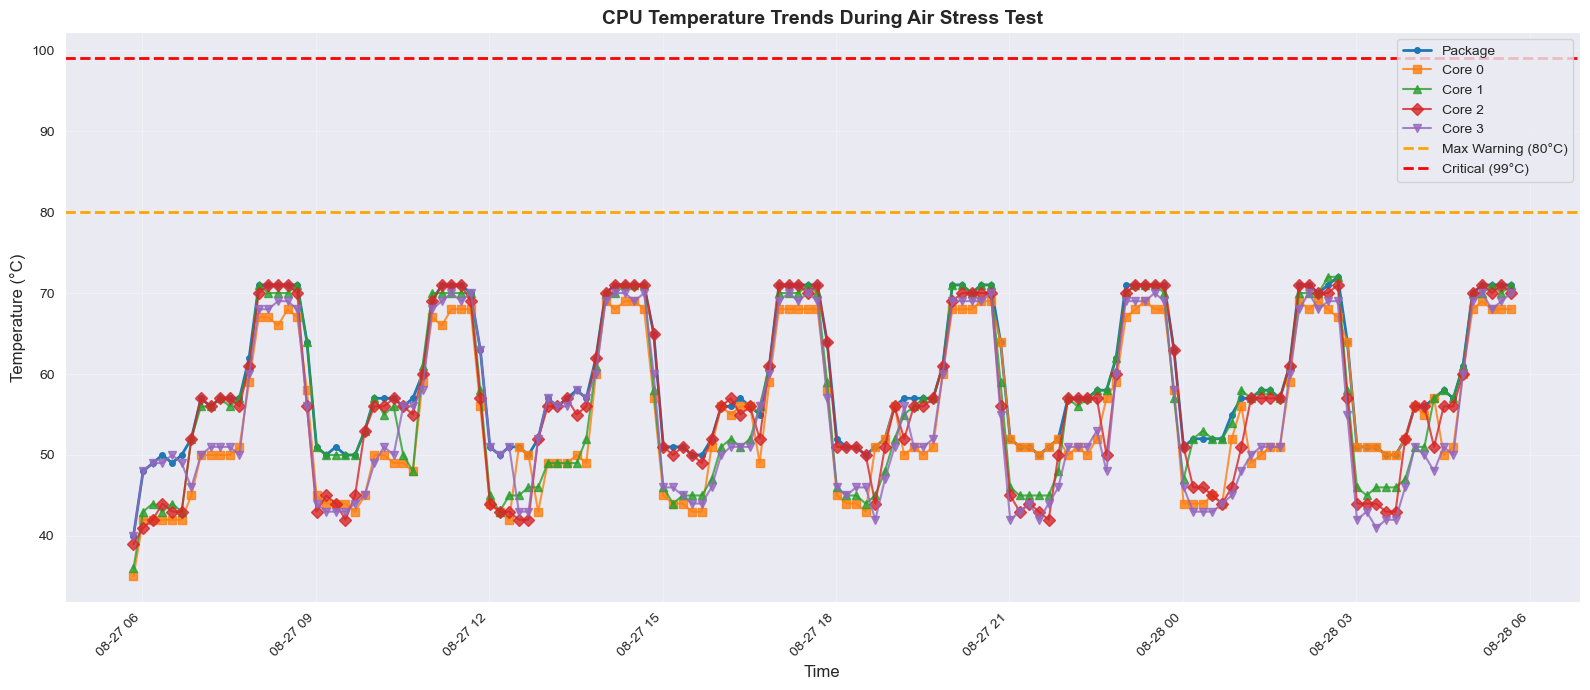

Temperature range: 40.0°C to 72.0°C


In [12]:
# Plot temperature trends
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(temps_df['timestamp'], temps_df['Package'], marker='o', label='Package', linewidth=2, markersize=4)
ax.plot(temps_df['timestamp'], temps_df['Core_0'], marker='s', label='Core 0', alpha=0.8, linewidth=1.5)
ax.plot(temps_df['timestamp'], temps_df['Core_1'], marker='^', label='Core 1', alpha=0.8, linewidth=1.5)
ax.plot(temps_df['timestamp'], temps_df['Core_2'], marker='D', label='Core 2', alpha=0.8, linewidth=1.5)
ax.plot(temps_df['timestamp'], temps_df['Core_3'], marker='v', label='Core 3', alpha=0.8, linewidth=1.5)

ax.axhline(y=80, color='orange', linestyle='--', label='Max Warning (80°C)', linewidth=2)
ax.axhline(y=99, color='red', linestyle='--', label='Critical (99°C)', linewidth=2)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_title('CPU Temperature Trends During Air Stress Test', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Temperature range: {temps_df['Package'].min():.1f}°C to {temps_df['Package'].max():.1f}°C")

## Core Temperature Comparison

Core Temperature Statistics:
         Mean   Max   Min  Std Dev
Core_0  55.07  69.0  35.0     9.36
Core_1  56.86  72.0  36.0     9.88
Core_2  57.01  71.0  39.0    10.01
Core_3  55.06  70.0  40.0     9.97


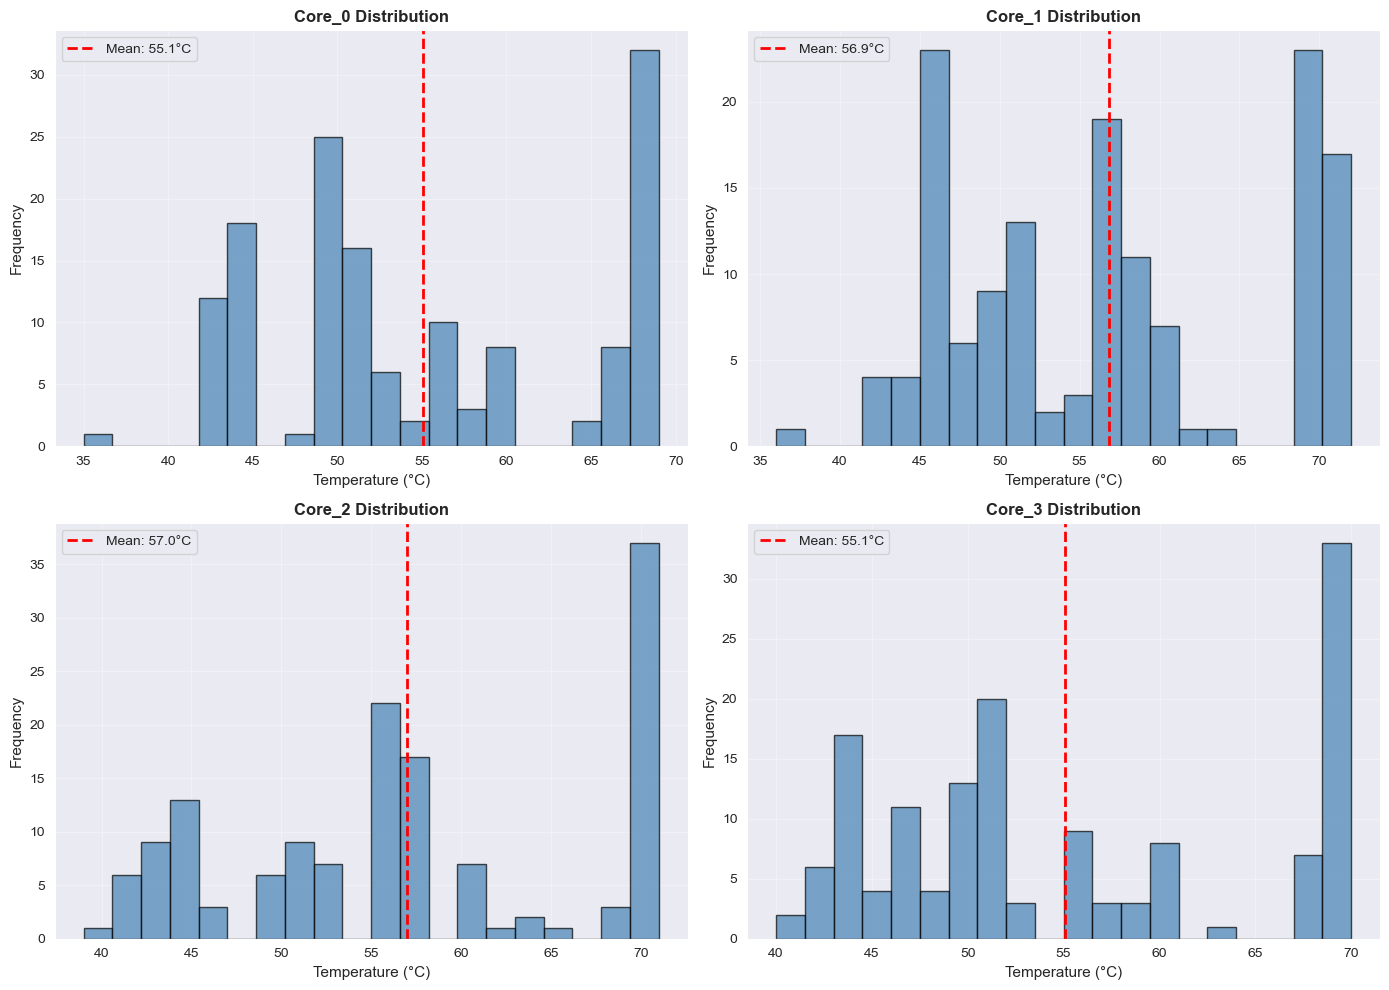

In [6]:
# Calculate statistics for each core
core_stats = pd.DataFrame({
    'Mean': temps_df[['Core_0', 'Core_1', 'Core_2', 'Core_3']].mean(),
    'Max': temps_df[['Core_0', 'Core_1', 'Core_2', 'Core_3']].max(),
    'Min': temps_df[['Core_0', 'Core_1', 'Core_2', 'Core_3']].min(),
    'Std Dev': temps_df[['Core_0', 'Core_1', 'Core_2', 'Core_3']].std()
})

print("Core Temperature Statistics:")
print(core_stats.round(2))

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cores = ['Core_0', 'Core_1', 'Core_2', 'Core_3']

for idx, core in enumerate(cores):
    ax = axes[idx // 2, idx % 2]
    ax.hist(temps_df[core], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(temps_df[core].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {temps_df[core].mean():.1f}°C')
    ax.set_xlabel('Temperature (°C)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{core} Distribution', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Thermal Cycling Analysis

In [7]:
# Identify thermal cycling patterns
# Calculate temperature changes between consecutive readings
temps_df['Package_Delta'] = temps_df['Package'].diff()
temps_df['Avg_Core_Temp'] = temps_df[['Core_0', 'Core_1', 'Core_2', 'Core_3']].mean(axis=1)

# Identify heating and cooling phases
temps_df['Phase'] = 'Stable'
temps_df.loc[temps_df['Package_Delta'] > 1, 'Phase'] = 'Heating'
temps_df.loc[temps_df['Package_Delta'] < -1, 'Phase'] = 'Cooling'

# Count cycles
phase_transitions = (temps_df['Phase'] != temps_df['Phase'].shift()).sum()
heating_phases = (temps_df['Phase'] == 'Heating').sum()
cooling_phases = (temps_df['Phase'] == 'Cooling').sum()

print(f"Thermal Cycling Summary:")
print(f"  Total measurements: {len(temps_df)}")
print(f"  Phase transitions: {phase_transitions}")
print(f"  Heating phases: {heating_phases}")
print(f"  Cooling phases: {cooling_phases}")
print(f"  Stable phases: {(temps_df['Phase'] == 'Stable').sum()}")
print(f"\nTemperature Delta Statistics:")
print(f"  Max increase: {temps_df['Package_Delta'].max():.2f}°C")
print(f"  Max decrease: {temps_df['Package_Delta'].min():.2f}°C")

Thermal Cycling Summary:
  Total measurements: 144
  Phase transitions: 49
  Heating phases: 32
  Cooling phases: 14
  Stable phases: 98

Temperature Delta Statistics:
  Max increase: 10.00°C
  Max decrease: -14.00°C


## Thermal Load Phases

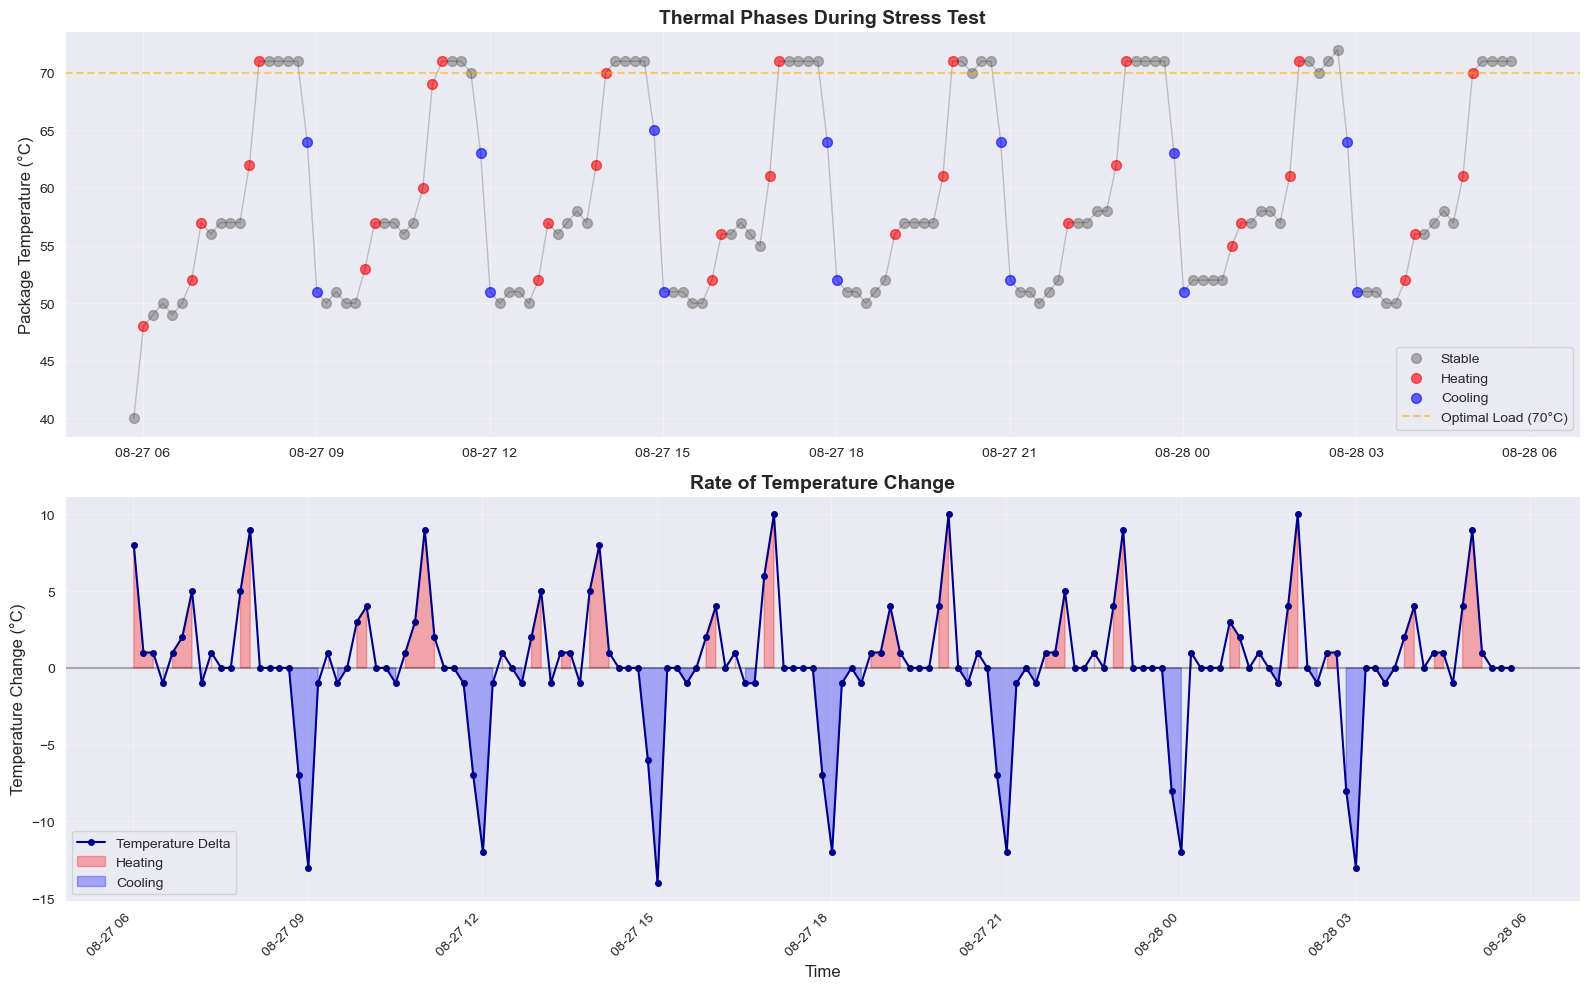

In [8]:
# Plot thermal phases
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Temperature with phase coloring
phase_colors = {'Heating': 'red', 'Cooling': 'blue', 'Stable': 'gray'}
for phase in ['Stable', 'Heating', 'Cooling']:
    mask = temps_df['Phase'] == phase
    ax1.scatter(temps_df[mask]['timestamp'], temps_df[mask]['Package'], 
               color=phase_colors[phase], label=phase, s=50, alpha=0.6)

ax1.plot(temps_df['timestamp'], temps_df['Package'], color='black', alpha=0.2, linewidth=1)
ax1.axhline(y=70, color='orange', linestyle='--', alpha=0.5, label='Optimal Load (70°C)')
ax1.set_ylabel('Package Temperature (°C)', fontsize=12)
ax1.set_title('Thermal Phases During Stress Test', fontsize=14, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Plot 2: Temperature delta (rate of change)
ax2.plot(temps_df['timestamp'][1:], temps_df['Package_Delta'][1:], marker='o', 
        color='darkblue', linewidth=1.5, markersize=4, label='Temperature Delta')
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.fill_between(temps_df['timestamp'][1:], temps_df['Package_Delta'][1:], 0, 
                  where=(temps_df['Package_Delta'][1:] > 0), alpha=0.3, color='red', label='Heating')
ax2.fill_between(temps_df['timestamp'][1:], temps_df['Package_Delta'][1:], 0, 
                  where=(temps_df['Package_Delta'][1:] <= 0), alpha=0.3, color='blue', label='Cooling')
ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylabel('Temperature Change (°C)', fontsize=12)
ax2.set_title('Rate of Temperature Change', fontsize=14, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Core-to-Core Temperature Variance

Core Temperature Consistency:
  Mean variance between cores: 9.05
  Max variance between cores: 24.92
  Mean max-min difference: 5.81°C
  Max max-min difference: 10.00°C


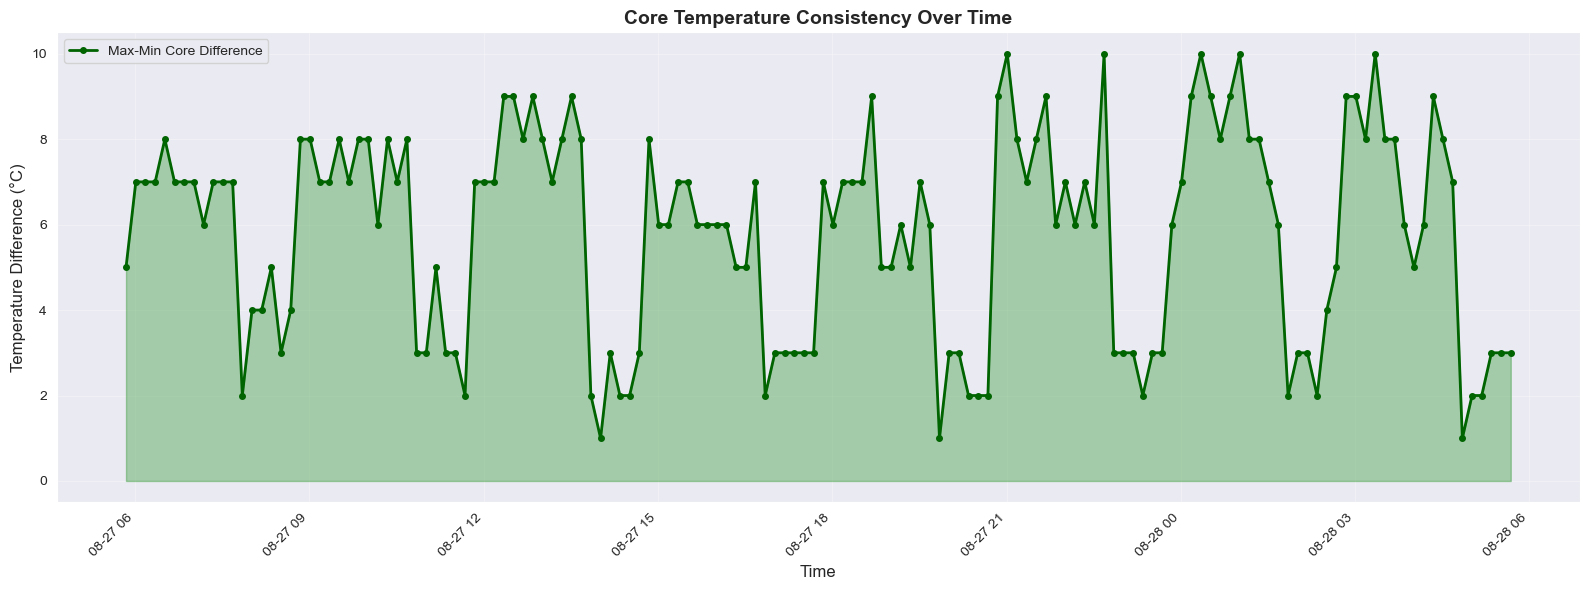

In [10]:
# Analyze core temperature consistency
temps_df['Core_Variance'] = temps_df[['Core_0', 'Core_1', 'Core_2', 'Core_3']].var(axis=1)
temps_df['Core_Max_Min_Diff'] = temps_df[['Core_0', 'Core_1', 'Core_2', 'Core_3']].max(axis=1) - temps_df[['Core_0', 'Core_1', 'Core_2', 'Core_3']].min(axis=1)

print("Core Temperature Consistency:")
print(f"  Mean variance between cores: {temps_df['Core_Variance'].mean():.2f}")
print(f"  Max variance between cores: {temps_df['Core_Variance'].max():.2f}")
print(f"  Mean max-min difference: {temps_df['Core_Max_Min_Diff'].mean():.2f}°C")
print(f"  Max max-min difference: {temps_df['Core_Max_Min_Diff'].max():.2f}°C")

# Plot variance over time
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(temps_df['timestamp'], temps_df['Core_Max_Min_Diff'], marker='o', 
       color='darkgreen', linewidth=2, markersize=4, label='Max-Min Core Difference')
ax.fill_between(temps_df['timestamp'], temps_df['Core_Max_Min_Diff'], alpha=0.3, color='green')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Temperature Difference (°C)', fontsize=12)
ax.set_title('Core Temperature Consistency Over Time', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Summary Statistics and Conclusions

In [11]:
# Comprehensive summary
print("="*60)
print("STRESS TEST ANALYSIS SUMMARY")
print("="*60)

print(f"\nTest Duration:")
print(f"  Start: {temps_df['timestamp'].min()}")
print(f"  End: {temps_df['timestamp'].max()}")
print(f"  Duration: {temps_df['timestamp'].max() - temps_df['timestamp'].min()}")

print(f"\nPackage Temperature:")
print(f"  Min: {temps_df['Package'].min():.1f}°C")
print(f"  Max: {temps_df['Package'].max():.1f}°C")
print(f"  Mean: {temps_df['Package'].mean():.1f}°C")
print(f"  Std Dev: {temps_df['Package'].std():.1f}°C")

print(f"\nCore Temperature Averages:")
print(f"  Core 0 Mean: {temps_df['Core_0'].mean():.1f}°C")
print(f"  Core 1 Mean: {temps_df['Core_1'].mean():.1f}°C")
print(f"  Core 2 Mean: {temps_df['Core_2'].mean():.1f}°C")
print(f"  Core 3 Mean: {temps_df['Core_3'].mean():.1f}°C")

print(f"\nThermal Performance:")
print(f"  Time above 70°C: {(temps_df['Package'] > 70).sum()} readings")
print(f"  Time above 80°C: {(temps_df['Package'] > 80).sum()} readings")
print(f"  Peak temperature: {temps_df['Package'].max():.1f}°C")
print(f"  Thermal margin to critical (99°C): {99 - temps_df['Package'].max():.1f}°C")

print(f"\nThermal Cycling:")
print(f"  Total phase transitions: {phase_transitions}")
print(f"  Average cycle rate: {phase_transitions / (len(temps_df)-1) * 100:.2f}% of measurements")

print("\n" + "="*60)

STRESS TEST ANALYSIS SUMMARY

Test Duration:
  Start: 2026-08-27 05:50:39.747448-04:00
  End: 2026-08-28 05:40:44.877662-04:00
  Duration: 0 days 23:50:05.130214

Package Temperature:
  Min: 40.0°C
  Max: 72.0°C
  Mean: 59.2°C
  Std Dev: 8.2°C

Core Temperature Averages:
  Core 0 Mean: 55.1°C
  Core 1 Mean: 56.9°C
  Core 2 Mean: 57.0°C
  Core 3 Mean: 55.1°C

Thermal Performance:
  Time above 70°C: 34 readings
  Time above 80°C: 0 readings
  Peak temperature: 72.0°C
  Thermal margin to critical (99°C): 27.0°C

Thermal Cycling:
  Total phase transitions: 49
  Average cycle rate: 34.27% of measurements



## Run Comparison: Baseline (2026-08-27) vs Latest (2026-09-01)

Note: `stress_test_log_20260831_204442.csv` is excluded — it contains only 2 readings (aborted run).

In [ ]:
# Build cleaned temperature frames for both runs
def extract_temps(source):
    t = pd.DataFrame({
        'timestamp': source['timestamp'],
        'Package': source['coretemp-isa-0000:Package id 0:temp1_input'],
        'Core_0': source['coretemp-isa-0000:Core 0:temp2_input'],
        'Core_1': source['coretemp-isa-0000:Core 1:temp3_input'],
        'Core_2': source['coretemp-isa-0000:Core 2:temp4_input'],
        'Core_3': source['coretemp-isa-0000:Core 3:temp5_input'],
    })
    for col in ['Package', 'Core_0', 'Core_1', 'Core_2', 'Core_3']:
        t[col] = pd.to_numeric(t[col], errors='coerce')
    return t.dropna().reset_index(drop=True)

old_run = extract_temps(df_old)
new_run = extract_temps(df)

# Elapsed hours from each run's start (aligns runs on a common time axis)
old_run['elapsed_hrs'] = (old_run['timestamp'] - old_run['timestamp'].min()).dt.total_seconds() / 3600
new_run['elapsed_hrs'] = (new_run['timestamp'] - new_run['timestamp'].min()).dt.total_seconds() / 3600

print(f"Baseline (2026-08-27): {len(old_run)} readings over {old_run['elapsed_hrs'].max():.1f} hrs")
print(f"Latest   (2026-09-01): {len(new_run)} readings over {new_run['elapsed_hrs'].max():.1f} hrs")

# Side-by-side run statistics
def run_stats(t):
    return pd.Series({
        'Readings': len(t),
        'Duration (hrs)': round((t['timestamp'].max() - t['timestamp'].min()).total_seconds() / 3600, 2),
        'Package Min (°C)': t['Package'].min(),
        'Package Max (°C)': t['Package'].max(),
        'Package Mean (°C)': round(t['Package'].mean(), 2),
        'Package Std (°C)': round(t['Package'].std(), 2),
        'Core Mean Avg (°C)': round(t[['Core_0', 'Core_1', 'Core_2', 'Core_3']].mean().mean(), 2),
        'Readings > 70°C': int((t['Package'] > 70).sum()),
        'Readings > 80°C': int((t['Package'] > 80).sum()),
        'Max Core Spread (°C)': (t[['Core_0', 'Core_1', 'Core_2', 'Core_3']].max(axis=1)
                                 - t[['Core_0', 'Core_1', 'Core_2', 'Core_3']].min(axis=1)).max(),
    })

comparison = pd.DataFrame({
    '2026-08-27 (baseline)': run_stats(old_run),
    '2026-09-01 (latest)': run_stats(new_run),
})
comparison['Delta (latest - baseline)'] = (comparison['2026-09-01 (latest)']
                                           - comparison['2026-08-27 (baseline)']).round(2)

comparison

In [ ]:
# Visual comparison of the two runs
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Package temperature vs elapsed time
axes[0].plot(old_run['elapsed_hrs'], old_run['Package'], color='steelblue',
             linewidth=1.5, label='2026-08-27 (baseline)')
axes[0].plot(new_run['elapsed_hrs'], new_run['Package'], color='darkorange',
             linewidth=1.5, label='2026-09-01 (latest)')
axes[0].axhline(y=80, color='orange', linestyle='--', alpha=0.6, label='Max Warning (80°C)')
axes[0].axhline(y=99, color='red', linestyle='--', alpha=0.6, label='Critical (99°C)')
axes[0].set_xlabel('Elapsed Time (hrs)', fontsize=12)
axes[0].set_ylabel('Package Temperature (°C)', fontsize=12)
axes[0].set_title('Package Temperature vs Elapsed Time', fontsize=13, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Distribution overlay
axes[1].hist(old_run['Package'], bins=25, alpha=0.5, color='steelblue',
             label='2026-08-27 (baseline)', edgecolor='black')
axes[1].hist(new_run['Package'], bins=25, alpha=0.5, color='darkorange',
             label='2026-09-01 (latest)', edgecolor='black')
axes[1].axvline(old_run['Package'].mean(), color='steelblue', linestyle='--', linewidth=2,
                label=f"Baseline mean: {old_run['Package'].mean():.1f}°C")
axes[1].axvline(new_run['Package'].mean(), color='darkorange', linestyle='--', linewidth=2,
                label=f"Latest mean: {new_run['Package'].mean():.1f}°C")
axes[1].set_xlabel('Package Temperature (°C)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Package Temperature Distribution', fontsize=13, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Key run-to-run differences
print("=" * 60)
print("RUN-TO-RUN COMPARISON")
print("=" * 60)
print(f"Mean package temp: {old_run['Package'].mean():.1f}°C -> {new_run['Package'].mean():.1f}°C "
      f"({new_run['Package'].mean() - old_run['Package'].mean():+.1f}°C)")
print(f"Peak package temp: {old_run['Package'].max():.1f}°C -> {new_run['Package'].max():.1f}°C "
      f"({new_run['Package'].max() - old_run['Package'].max():+.1f}°C)")
print(f"Readings > 70°C:   {(old_run['Package'] > 70).sum()} -> {(new_run['Package'] > 70).sum()}")
print(f"Readings > 80°C:   {(old_run['Package'] > 80).sum()} -> {(new_run['Package'] > 80).sum()}")
print(f"Thermal margin to critical (99°C): {99 - new_run['Package'].max():.1f}°C on latest run")
print("=" * 60)